* `Import Libararis`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import chi2, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight

from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

* `Read Data`

In [2]:
file_path = os.path.join(os.getcwd(), "..", "Data", "Churn_Modelling.csv")
df = pd.read_csv(file_path)

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Adjust col names
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [4]:
# Drop first three columns

df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 859.5 KB


In [6]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


* ## `EDA`

In [7]:
df.isna().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [9]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [10]:
df["Exited"].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

In [11]:
df["Tenure"].value_counts()

Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64

In [12]:
df.dtypes

CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

* ## `Data Visualization & Handling Outliers`

 * > ### `Univarite Visualization`

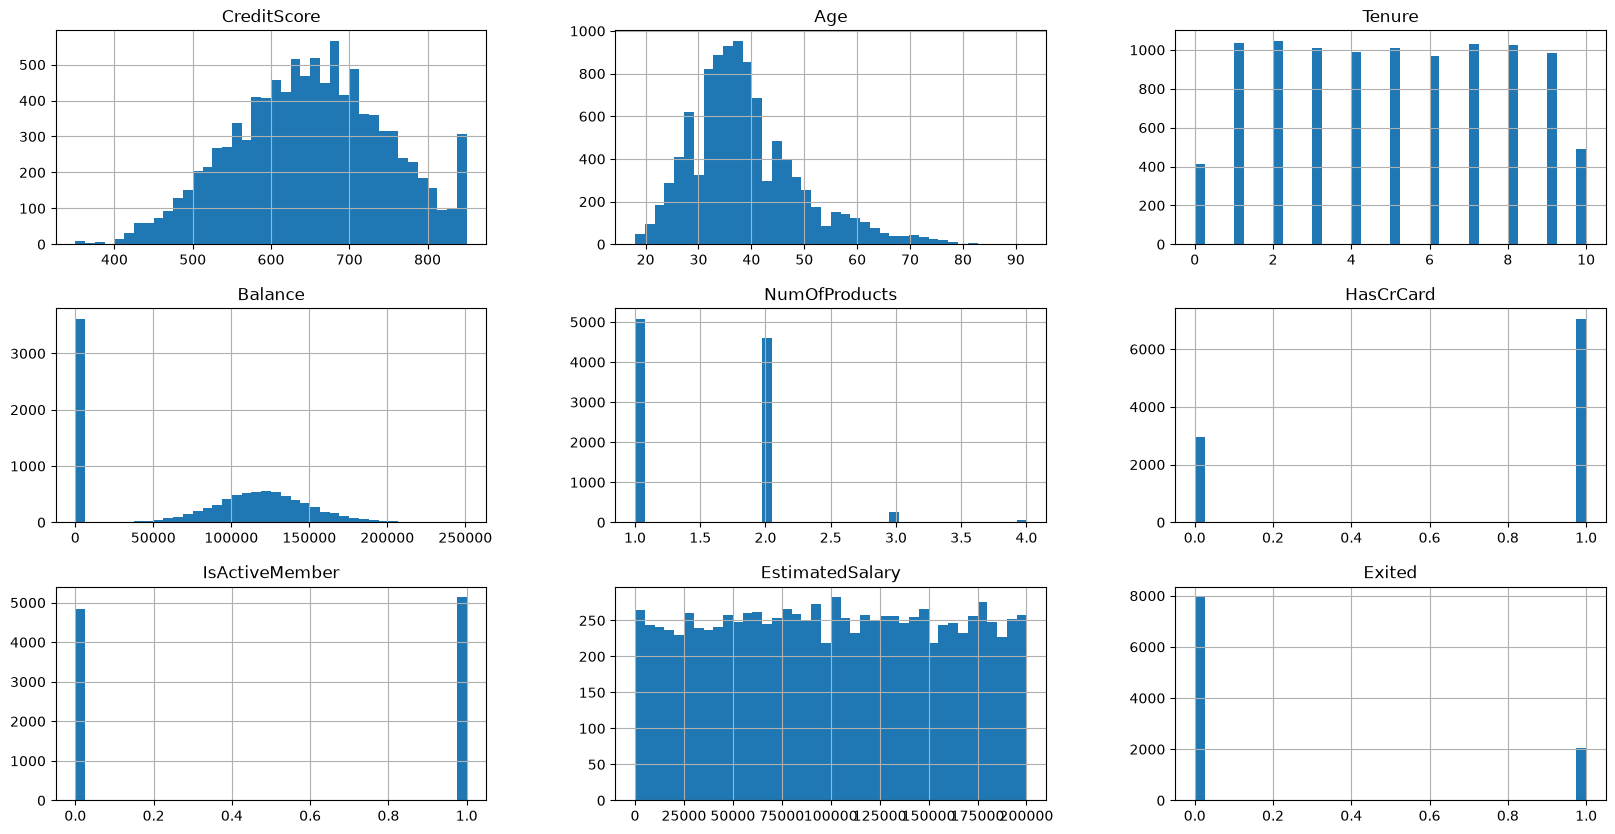

In [ ]:
## Numerical columns
df.hist(bins=40, figsize=(20, 10))
plt.show()

In [14]:
df.drop(index=df[df["Age"] > 80].index.tolist(), inplace=True)

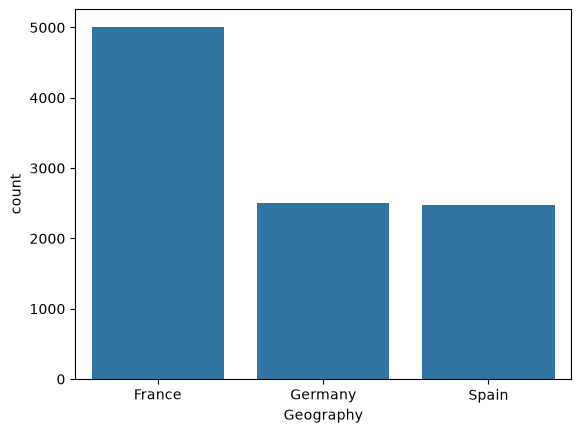

In [15]:
# countplot
sns.countplot(data=df, x='Geography', order=df["Geography"].value_counts(). index.tolist()) # title, xlabel, ylabel
plt.show()

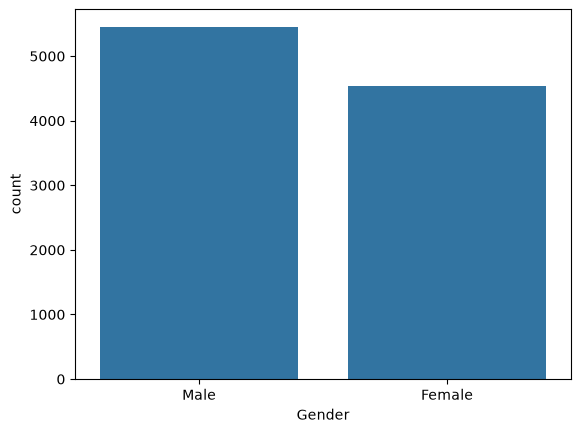

In [16]:
# counplot for Gender
sns.countplot(
    data=df, x="Gender", order=df["Gender"].value_counts().index.tolist()
)  # = title, xlabel, ylabel
plt.show()

<Axes: ylabel='EstimatedSalary'>

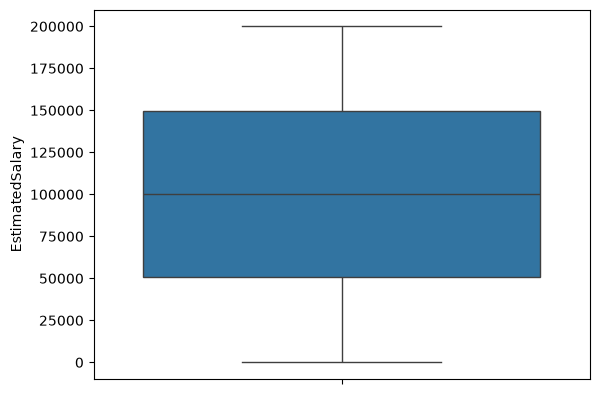

In [18]:
# Boxplot for (EstimatedSalary)
sns.boxplot(data=df, y="EstimatedSalary")

 * > ### `Bivarite Visualization`

In [19]:
# Averge salary per Gender
df[["Gender", "EstimatedSalary"]].groupby("Gender")["EstimatedSalary"].mean()

Gender
Female    100575.998277
Male       99671.901194
Name: EstimatedSalary, dtype: float64

<Axes: xlabel='Gender', ylabel='EstimatedSalary'>

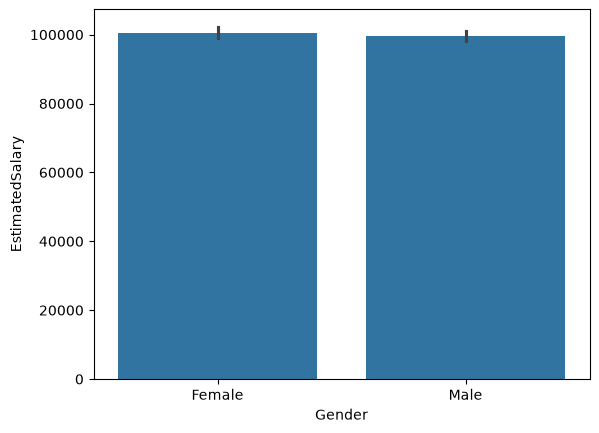

In [21]:
sns.barplot(data=df, y="EstimatedSalary", x="Gender",estimator = 'mean')

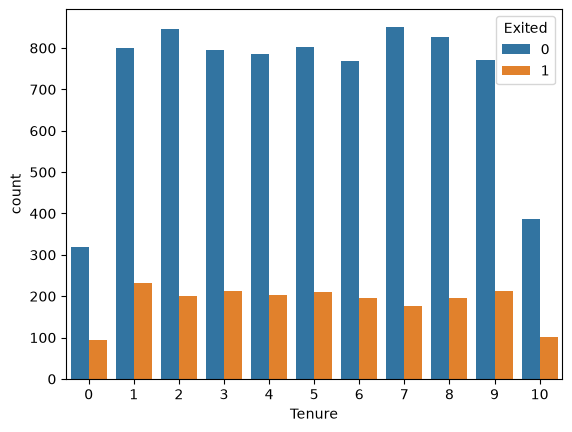

In [22]:
# Realation between Tenure and Exited
sns.countplot(data=df, x="Tenure", hue="Exited")  ## labels, title
plt.show()

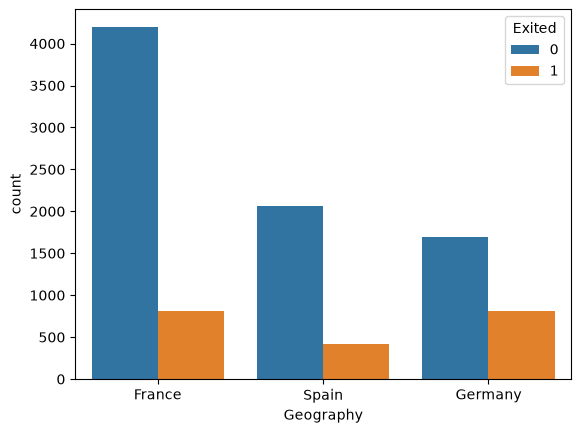

In [23]:
# Geography with Exited
sns.countplot(data=df, x="Geography", hue="Exited")  ## labels, titles
plt.show()

* `Split to train & Test the Data Set`

In [25]:
# to featueres & target
X = df.drop(columns=["Exited"])
y = df["Exited"]

# Split to train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=45, stratify=y
)

# Check shapes
print("X_train.shape \t", X_train.shape)
print("y_train.shape \t", y_train.shape)
print(" *** " * 10)
print("X_test.shape \t", X_test.shape)
print("y_test.shape \t", y_test.shape)


X_train.shape 	 (7990, 10)
y_train.shape 	 (7990,)
 ***  ***  ***  ***  ***  ***  ***  ***  ***  *** 
X_test.shape 	 (1998, 10)
y_test.shape 	 (1998,)


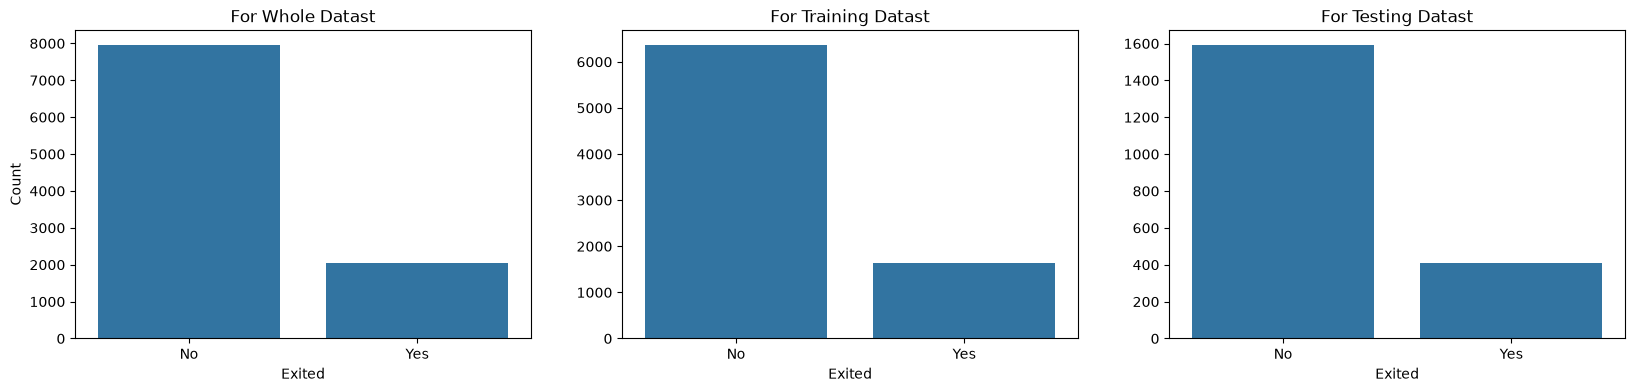

In [27]:
# plottting to check
fig, ax = plt.subplots(1, 3, figsize=(20, 4))

# Whole dataset
plt.sca(ax[0])
sns.countplot(x=y)
plt.title("For Whole Datast")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["No", "Yes"])

# train
plt.sca(ax[1])
sns.countplot(x = y_train)
plt.title("For Training Datast")
plt.ylabel("")
plt.xticks(ticks=[0, 1], labels=["No", "Yes"])

# test
plt.sca(ax[2])
sns.countplot(x=y_test)
plt.title("For Testing Datast")
plt.ylabel("")
plt.xticks(ticks=[0, 1], labels=["No", "Yes"])
plt.show()


* `Feature Selection & Preprocessing`

In [28]:
# slice columns
num_col = ["CreditScore", "Age", "Balance", "EstimatedSalary"]
cat_col = ["Geography", "Gender"]
ready_col = list(set(X_train.columns.tolist()) - set(num_col) - set(cat_col))

In [29]:
# Numerical cols & Target cols --> Anova
_, p_val = f_classif(X_train[num_col], y_train)
p_val

array([9.12989970e-002, 1.15359217e-149, 3.56368021e-025, 6.16127881e-001])

In [30]:
# Catigorical cols & Target cols --> chi2
_, p_cal = chi2(OrdinalEncoder().fit_transform(X_train[cat_col]), y_train)
p_cal

array([1.56448286e-03, 5.13986341e-10])

In [31]:
# Ready cols & Target cols --> chi2
_, p_ready = chi2(X_train[ready_col], y_train)
p_ready

array([6.55133468e-02, 7.15759804e-22, 6.69284702e-01, 6.36015039e-02])

In [32]:
num_pipline = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaling", StandardScaler())]
)

cat_pipline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(sparse_output=False, drop="first")),
    ]
)

ready_pipline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", num_pipline, num_col),
        ("categorical", cat_pipline, cat_col),
        ("ready", ready_pipline, ready_col),
    ]
)

# apply to train and test
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

* `Deal with imbalance dataset`

In [33]:
vals_count = 1 - np.bincount(y_train) / len(y_train)
vals_count = vals_count / sum(vals_count)

dic_weights = {}
for i in range(2):
    dic_weights[i] = vals_count[i]

print(dic_weights)

{0: np.float64(0.20387984981226537), 1: np.float64(0.7961201501877346)}


In [34]:
over = SMOTE(k_neighbors=5, sampling_strategy=0.7, random_state=42)
X_train_final_resample, y_train_resample = over.fit_resample(X_train_final, y_train)

In [35]:
MODEL_FOLDER_PATH = os.path.join(os.getcwd(), "..", "models")
os.makedirs(MODEL_FOLDER_PATH, exist_ok=True)

In [36]:
joblib.dump(preprocessor, os.path.join(MODEL_FOLDER_PATH, "preprocessor.pkl"))

['c:\\Users\\hp\\Desktop\\python projects\\churn-detection-project\\notebooks\\..\\models\\preprocessor.pkl']

* ### `Building Models`
    Let's consider the evaluation metric to  be f1_score

* > 1.Using Logistic Regression

In [ ]:
# 1.Using logisit -- without considering the imbalancing data
log_clf = LogisticRegression(C=1.5)
log_clf.fit(X_train_final, y_train)

# predict and evaluate
y_pred_train_log = log_clf.predict(X_train_final)
y_pred_test_log = log_clf.predict(X_test_final)

# Using f1 score
score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log = f1_score(y_test, y_pred_test_log)

print(f"The f1_score using Logistic model for Traning Dataset is {score_train_log}")
print(f"The f1_score using Logistic model for test Dataset is {score_test_log}")

The f1_score using Logistic model for Traning Dataset is 0.3088838268792711
The f1_score using Logistic model for test Dataset is 0.375


In [ ]:
# 1.Using logisit -- with considering the imbalancing data
log_clf = LogisticRegression(C=1.5, class_weight=dic_weights)
log_clf.fit(X_train_final, y_train)

# predict and evaluate
y_pred_train_log = log_clf.predict(X_train_final)
y_pred_test_log = log_clf.predict(X_test_final)

# Using f1 score
score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log = f1_score(y_test, y_pred_test_log)

print(f"The f1_score using Logistic model for Traning Dataset is {score_train_log}")
print(f"The f1_score using Logistic model for test Dataset is {score_test_log}")

The f1_score using Logistic model for Traning Dataset is 0.4981380065717415
The f1_score using Logistic model for test Dataset is 0.499151103565365


In [40]:
# 1.Using logisit -- with considering the imbalancing data --> SMOTE
log_clf = LogisticRegression(C=1.5)
log_clf.fit(X_train_final_resample, y_train_resample)

# predict and evaluate
y_pred_train_log = log_clf.predict(X_train_final)
y_pred_test_log = log_clf.predict(X_test_final)

# Using f1 score
score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log = f1_score(y_test, y_pred_test_log)

print(f"The f1_score using Logistic model for Traning Dataset is {score_train_log}")
print(f"The f1_score using Logistic model for test Dataset is {score_test_log}")

The f1_score using Logistic model for Traning Dataset is 0.4994600431965443
The f1_score using Logistic model for test Dataset is 0.5062761506276151


<Axes: >

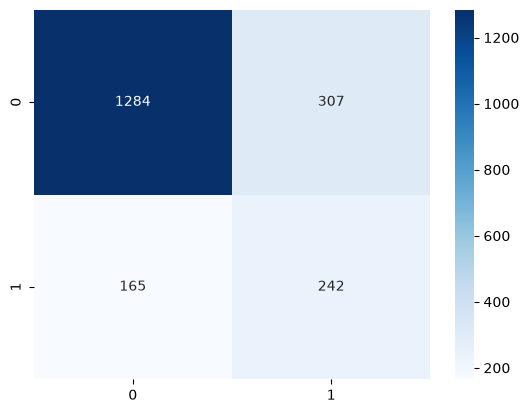

In [ ]:
## Confusion Matrix
sns.heatmap(
    confusion_matrix(y_true=y_test, y_pred=y_pred_test_log),
    cmap="Blues",
    annot=True,
    fmt="d",
)

In [42]:
print(classification_report(y_true=y_test, y_pred=y_pred_test_log))

              precision    recall  f1-score   support

           0       0.89      0.81      0.84      1591
           1       0.44      0.59      0.51       407

    accuracy                           0.76      1998
   macro avg       0.66      0.70      0.68      1998
weighted avg       0.80      0.76      0.78      1998



* `Random Forest Model`

In [54]:
# 2.Using Random Forest -- with considering the imbalancing data
forest_clf = RandomForestClassifier(
    n_estimators=250, max_depth=8, random_state=45, class_weight=dic_weights
)
forest_clf.fit(X_train_final, y_train)

# predict and evaluate
y_pred_train_forest = forest_clf.predict(X_train_final)
y_pred_test_forest = forest_clf.predict(X_test_final)

# Using F1 score
score_train_forest = f1_score(y_train, y_pred_train_forest)
score_test_forest = f1_score(y_test, y_pred_test_forest)

print(
    f"The f1_score using Random Forest model for Traning Dataset is {score_train_forest}"
)
print(f"The f1_score using Random Forest model for test Dataset is {score_test_forest}")

The f1_score using Random Forest model for Traning Dataset is 0.6756967960406356
The f1_score using Random Forest model for test Dataset is 0.6086956521739131


In [53]:
# 2.Using Random Forest -- with considering the imbalancing data --> SMOTE
forest_clf = RandomForestClassifier(n_estimators=250, max_depth=8, random_state=45)
forest_clf.fit(X_train_final_resample, y_train_resample)

# predict and evaluate
y_pred_train_forest = forest_clf.predict(X_train_final)
y_pred_test_forest = forest_clf.predict(X_test_final)

# Using F1 score
score_train_forest = f1_score(y_train, y_pred_train_forest)
score_test_forest = f1_score(y_test, y_pred_test_forest)

print(
    f"The f1_score using Random Forest model for Traning Dataset is {score_train_forest}"
)
print(f"The f1_score using Random Forest model for test Dataset is {score_test_forest}")

The f1_score using Random Forest model for Traning Dataset is 0.651394422310757
The f1_score using Random Forest model for test Dataset is 0.6068601583113457


* `RF Tuning` 

In [55]:
# Tuning the Random Forest Model to Get the best parmaters
forest_base_clf = RandomForestClassifier(n_estimators=250, max_depth=8, random_state=45)

# Parametrs to get the best of it
parms_best_grid = {
    "n_estimators": np.arange(50, 400, 50),
    "max_depth": np.arange(2, 10, 2),
}

# Tuning Using GridSearch and Cross Validation
grid_search_forest = GridSearchCV(
    estimator=forest_base_clf,
    param_grid=parms_best_grid,
    cv=5,
    n_jobs=-1,
    verbose=6,
    scoring="f1",
)
grid_search_forest.fit(X_train_final, y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=45)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([2, 4, 6, 8]), 'n_estimators': array([ 50, 1...50, 300, 350])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",6
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digit

In [58]:
# The Best Parameters
grid_search_forest.best_params_

{'max_depth': np.int64(8), 'n_estimators': np.int64(50)}

In [59]:
# The best model with the best parameters
forest_tuned = grid_search_forest.best_estimator_

# predict and evaluate
y_pred_train_forest_tuned = forest_tuned.predict(X_train_final)
y_pred_test_forest_tuned = forest_tuned.predict(X_test_final)

# Using F1 score
score_train_forest_tuned = f1_score(y_train, y_pred_train_forest_tuned)
score_test_forest_tuned = f1_score(y_test, y_pred_test_forest_tuned)

print(
    f"The f1_score using Random Forest model Tuned for Traning Dataset is {score_train_forest_tuned}"
)
print(
    f"The f1_score using Random Forest model Tuned for test Dataset is {score_test_forest_tuned}"
)

The f1_score using Random Forest model Tuned for Traning Dataset is 0.6211576846307385
The f1_score using Random Forest model Tuned for test Dataset is 0.567398119122257


In [ ]:
# Download the best Random Forest Model
joblib.dump(forest_tuned, os.path.join(MODEL_FOLDER_PATH, "forest_tuned.pkl"))

['c:\\Users\\hp\\Desktop\\python projects\\churn-detection-project\\notebooks\\..\\models\\forest_tuned.pkl']

In [64]:
# Get the features out from the preprocessor
features_after = [name.split('__')[1] for name in preprocessor.get_feature_names_out()]
features_after

['CreditScore',
 'Age',
 'Balance',
 'EstimatedSalary',
 'Geography_Germany',
 'Geography_Spain',
 'Gender_Male',
 'NumOfProducts',
 'IsActiveMember',
 'HasCrCard',
 'Tenure']

In [65]:
# Feature Importance from RF
forest_tuned_importance = pd.DataFrame({'feature': features_after,
                                            'importance': forest_tuned.feature_importances_}).sort_values('importance', ascending=False)

forest_tuned_importance

,feature,importance
1,Age,0.352398
7,NumOfProducts,0.284845
8,IsActiveMember,0.080941
2,Balance,0.078837
4,Geography_Germany,0.052213
0,CreditScore,0.050565
3,EstimatedSalary,0.047813
10,Tenure,0.024546
6,Gender_Male,0.016182
9,HasCrCard,0.006201
